In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose


df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['suedbruecke'].sum())
header = 'suedbruecke'

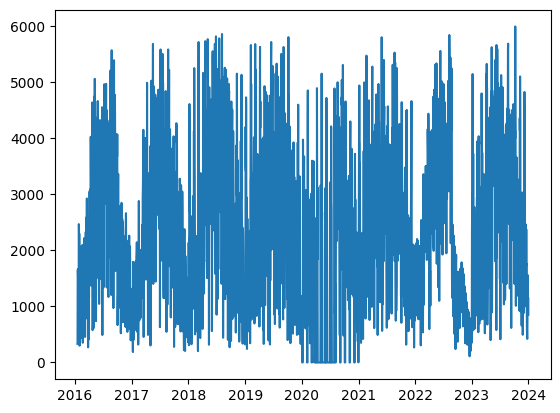

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

In [4]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [5]:

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



Seasonal ARIMA

In [6]:
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
df_unstack = df_unstack.unstack(['month'])
df_unstack

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,21620,41753,48168,76820,93533,83799,101416,104917,107964,61261,49945,41213
2017,36339,43146,79037,72181,103031,107738,105658,98137,80779,72205,60421,33500
2018,54674,54016,64587,100033,106007,111081,116891,108337,94393,83379,76100,57291
2019,59701,79255,75732,84724,96882,103408,107227,108003,91128,86825,73489,57447
2020,60807,49561,40119,19989,20313,21703,35143,88143,87106,67419,60179,45138
2021,59056,75485,74266,81293,78316,88673,81028,90629,93415,70873,57207,53521
2022,48358,48835,90106,79839,114710,110928,111943,120085,40729,37362,31384,16320
2023,59511,64591,79357,88801,106579,114885,93160,108937,97175,80759,69966,52257


Monatlich


In [7]:
df_month = df
df_month.set_index([df_month.index.year, df_month.index.month])
df_month['month'] = df_month.index.month
df_month['year'] = df_month.index.year
df_month = df_month.groupby(['year', 'month']).sum().reset_index()
monthly_pattern = df_month.groupby('month')[header].mean()
print(monthly_pattern)

month
1      50008.250
2      57080.250
3      68921.500
4      75460.000
5      89921.375
6      92776.875
7      94058.250
8     103398.500
9      86586.125
10     70010.375
11     59836.375
12     44585.875
Name: suedbruecke, dtype: float64


In [8]:
df_month.index

RangeIndex(start=0, stop=96, step=1)

In [9]:
df_month['year-month'] = df_month['year'].astype(str) + '-' + df_month['month'].astype(str).str.zfill(2)
tmp = pd.DataFrame()
tmp['year-month'] =  df_month['year-month']
tmp[header] = df_month[header]
df_month = tmp

In [10]:
df_month['year-month'] = pd.to_datetime(df_month['year-month'])
df_month.index = df_month['year-month']
df_month

,year-month,suedbruecke
year-month,,
2016-01-01,2016-01-01,21620
2016-02-01,2016-02-01,41753
2016-03-01,2016-03-01,48168
2016-04-01,2016-04-01,76820
2016-05-01,2016-05-01,93533
...,...,...
2023-08-01,2023-08-01,108937
2023-09-01,2023-09-01,97175
2023-10-01,2023-10-01,80759


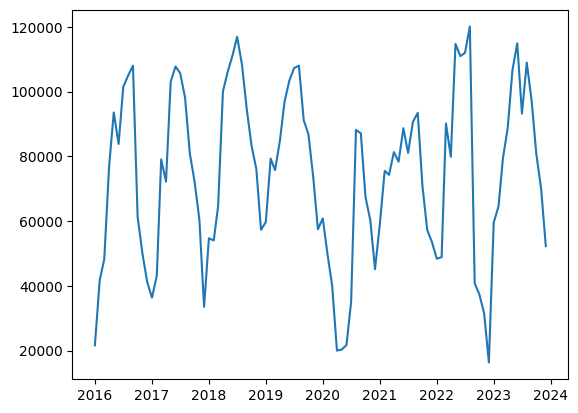

In [11]:
plt.plot(df_month[header])

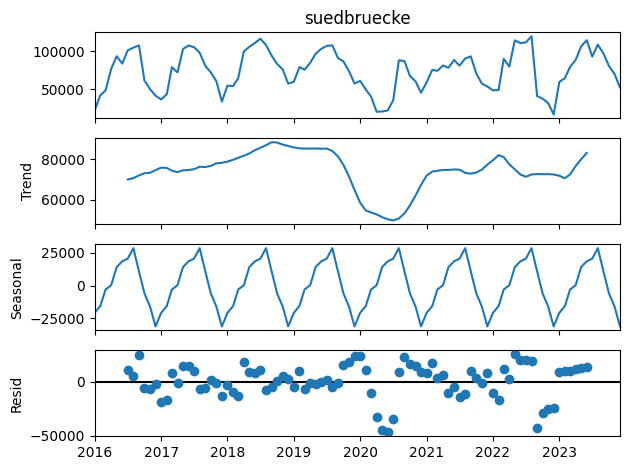

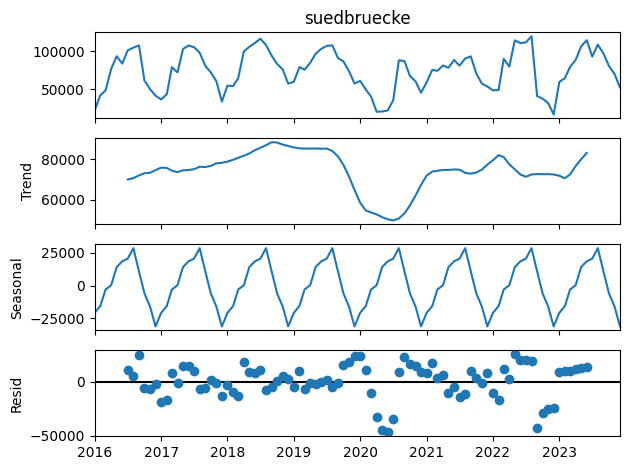

In [12]:
decomposition = seasonal_decompose(df_month[header], period=12)
decomposition.plot()

In [13]:
result = adfuller(df_month[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -4.9037
p-value = 0.0000


In [14]:
maximum = max(df_month[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df_month[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df_month['scaled'] = scaled_data
df_month['log'] = np.log(df_month['scaled'])
df_month

,year-month,suedbruecke,scaled,log
year-month,,,,
2016-01-01,2016-01-01,21620,6134.524792,8.721688
2016-02-01,2016-02-01,41753,29433.818118,10.289900
2016-03-01,2016-03-01,48168,36857.697653,10.514820
2016-04-01,2016-04-01,76820,70015.764130,11.156476
2016-05-01,2016-05-01,93533,89357.198063,11.400397
...,...,...,...,...
2023-08-01,2023-08-01,108937,107183.767099,11.582300
2023-09-01,2023-09-01,97175,93571.971137,11.446486
2023-10-01,2023-10-01,80759,74574.246046,11.219550


In [15]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df_month) * 0.9)
df_train = df_month.iloc[:end_train]
df_test = df_month.iloc[end_train:]

In [16]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -2.6835
P-value = 0.0769


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_9980\2308934689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)


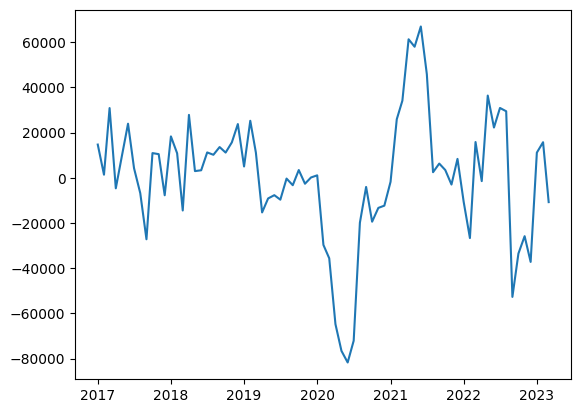

In [17]:
plt.plot(df_train['differences'])

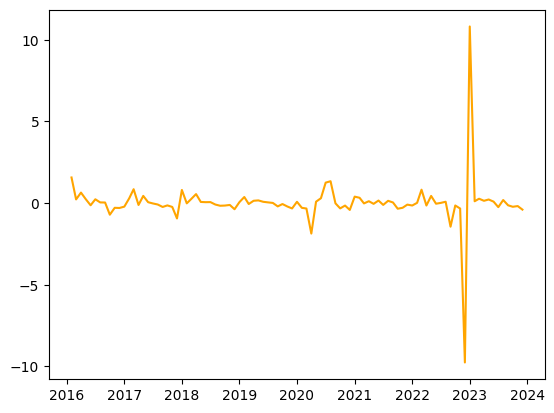

In [18]:
df_month['first_logged_diff'] = df_month['log'].diff().dropna()

plt.plot(df_month['first_logged_diff'], color='orange')
plt.show()

In [19]:
result = adfuller(df_month['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -9.9486
P-value = 0.0000


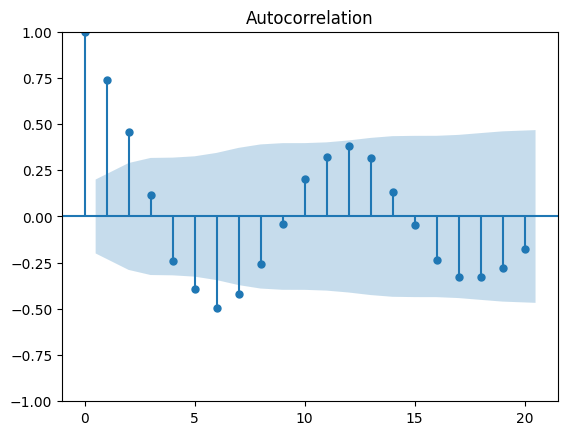

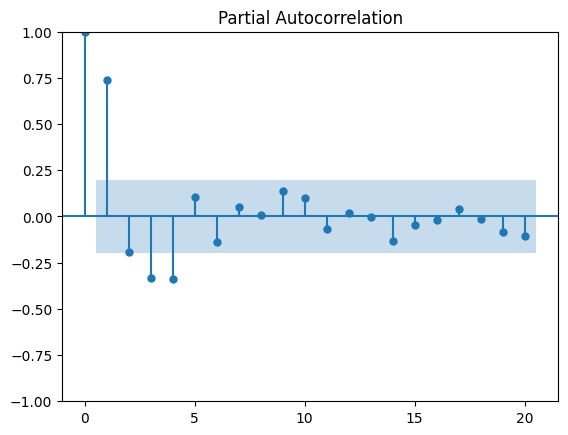

In [20]:
plot_acf(df_month[header])
plot_pacf(df_month[header])
plt.show()

In [21]:
#Mittelwertbereinigung
df_month['month'] = df_month['year-month'].dt.month
df_month['monthly_mean'] = df_month.groupby('month')['log'].transform('mean')
df_month['cleaned_by_mean'] = df_month['log'] - df_month['monthly_mean']
display(df_month)

,year-month,suedbruecke,scaled,log,first_logged_diff,month,monthly_mean,cleaned_by_mean
year-month,,,,,,,,
2016-01-01,2016-01-01,21620,6134.524792,8.721688,NaN,1,10.411868,-1.690180
2016-02-01,2016-02-01,41753,29433.818118,10.289900,1.568212,2,10.708807,-0.418907
2016-03-01,2016-03-01,48168,36857.697653,10.514820,0.224920,3,10.958199,-0.443379
2016-04-01,2016-04-01,76820,70015.764130,11.156476,0.641656,4,10.889720,0.266756
2016-05-01,2016-05-01,93533,89357.198063,11.400397,0.243921,5,11.091071,0.309326
...,...,...,...,...,...,...,...,...
2023-08-01,2023-08-01,108937,107183.767099,11.582300,0.186745,8,11.514070,0.068231
2023-09-01,2023-09-01,97175,93571.971137,11.446486,-0.135814,9,11.247435,0.199051
2023-10-01,2023-10-01,80759,74574.246046,11.219550,-0.226936,10,10.983221,0.236329


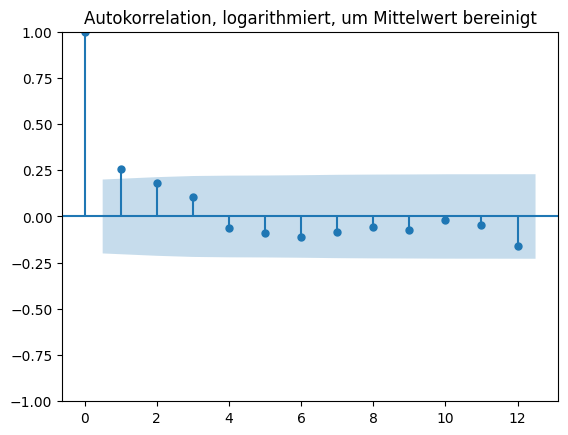

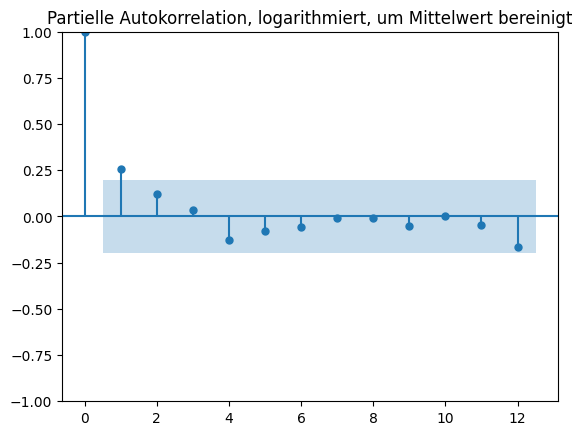

In [22]:
lags  = 12
plot_acf(df_month['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df_month['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()

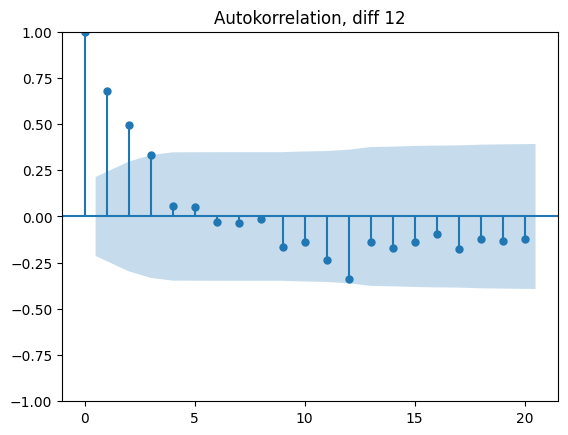

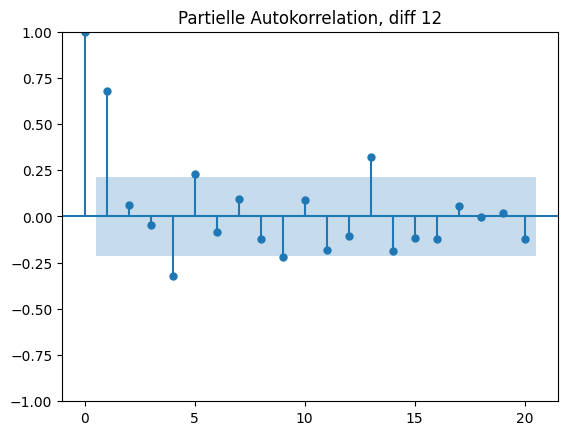

In [23]:
diffs = df_month[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [24]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df_month) * 0.9)
df_train_seas = df_month.iloc[:end_train]
df_test_seas = df_month.iloc[end_train:]

df_train_seas = df_train_seas.asfreq('MS')

seasonal = 12
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0,1], seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,12) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible st

ARIMA (0,0,0)x(0,1,0,12) LL -138.8163, AIC: 279.6325
ARIMA (0,1,0)x(0,1,0,12) LL -148.6603, AIC: 299.3206
ARIMA (1,0,0)x(0,1,1,12) LL -133.1449, AIC: 272.2897
ARIMA (1,0,0)x(0,1,2,12) LL -133.1413, AIC: 274.2825
ARIMA (1,1,0)x(0,1,2,12) LL -139.9002, AIC: 287.8004
ARIMA (0,0,1)x(0,1,2,12) LL -133.8792, AIC: 275.7585
ARIMA (0,1,1)x(0,1,2,12) LL -136.5626, AIC: 279.1253
ARIMA (0,1,1)x(2,1,0,12) LL -135.4382, AIC: 278.8764


In [31]:
print(result3.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                  log   No. Observations:                   87
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -133.145
Date:                              Mon, 10 Feb 2025   AIC                            272.290
Time:                                      22:26:56   BIC                            279.242
Sample:                                  01-01-2016   HQIC                           275.066
                                       - 03-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2903      0.054      5.383      0.000       0.185       0.396
ma.S.L12      -0.40

In [26]:
start_date = '2023-04-01'
end_date = '2024-12-01'
results_final = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2023-04-01', end='2024-12-01')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


            predicted_mean       unlogged    new_predict
2023-04-01       11.373983   87027.843160   91520.196367
2023-05-01       11.701698  120776.617432  120682.629017
2023-06-01       11.701205  120717.050772  120631.157260
2023-07-01       11.635895  113085.045626  114036.315199
2023-08-01       11.675649  117671.150798  117999.184551
2023-09-01       10.227152   27643.672318   40206.128819
2023-10-01       10.079291   23844.077773   36922.886022
2023-11-01        9.738965   16965.967411   30979.487054
2023-12-01       -0.013510       0.986580   16319.988404
2024-01-01       10.783238   48205.976230   57974.086794
2024-02-01       10.882681   53246.143823   62329.313054
2024-03-01       11.184985   72040.591867   78569.660655
2024-04-01       11.353952   85301.872526   90028.779169
2024-05-01       11.701955  120807.698270  120709.486077
2024-06-01       11.693013  119732.163653  119780.112891
2024-07-01       11.630707  112499.863643  113530.657423
2024-08-01       11.665793  116

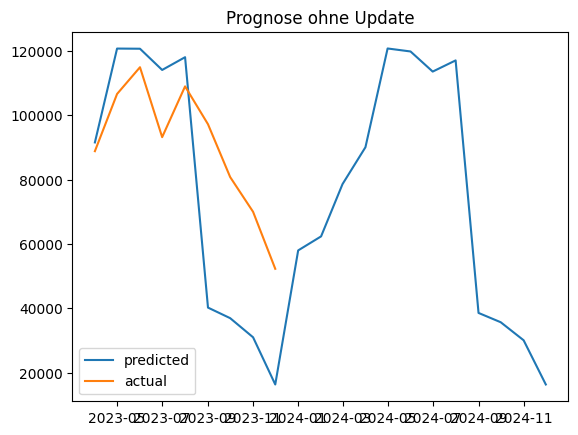

mean absolute error (mae): ARIMA: 25359.5547
mean squared error (mse): ARIMA: 970638066.1287
mean absolute percentage error (mape): ARIMA: 0.3216


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_9980\1951914538.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_9980\1951914538.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykernel

In [27]:
plt.plot(y_pred_no_update['new_predict'], label='predicted')
plt.plot(df_test_seas[header], label='actual')

plt.title('Prognose ohne Update')
plt.legend()
plt.show()

plt.show()
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = y_pred_no_update.loc[start_date:end_date, 'new_predict']

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mse_arima = np.mean(np.square(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

In [32]:
arima = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal), freq='MS')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_month['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal), freq='MS')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2023-04-01', end='2024-12-01')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,predicted_mean,unlogged,final_data
2023-04-01,10.948698,56879.917440,65469.269413
2023-05-01,11.324649,82838.529207,87900.195681
2023-06-01,11.356737,85539.784033,90234.359325
2023-07-01,11.473127,96098.341929,99358.045746
2023-08-01,11.581117,107057.081108,108827.530197
2023-09-01,10.706177,44630.703115,54884.680921
2023-10-01,10.706934,44664.507588,54913.891483
2023-11-01,10.406058,33059.300352,44885.791746
2023-12-01,4.522011,92.020469,16398.651103
2024-01-01,12.587302,292816.783211,269343.131682


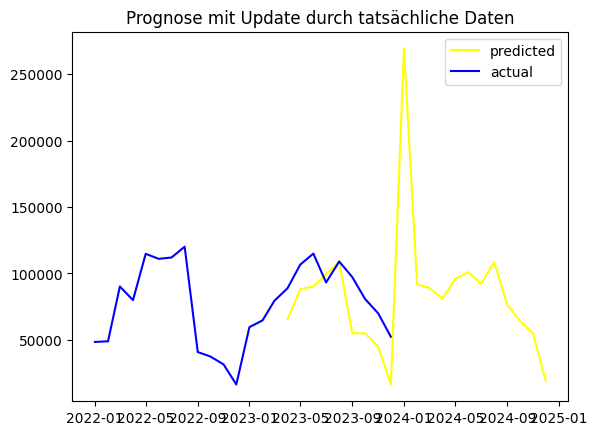

In [33]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-01-01'
end_date = '2024-12-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df_month.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [34]:
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 22449.1862
mean squared error (mse): ARIMA: 656736441.9030
mean absolute percentage error (mape): ARIMA: 0.2800
